<a href="https://colab.research.google.com/github/asad-iqbal78/ai-internship/blob/main/week_3_titanic_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 3 — Titanic Survival Classification

# In this notebook, I will build a machine learning model to predict whether a Titanic passenger survived or not.

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"

df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df.shape

(891, 12)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [5]:
X = df[["Pclass", "Sex", "Age", "SibSp", "Parch", "Fare"]]
y = df["Survived"]

In [6]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,male,22.0,1,0,7.2500
1,1,female,38.0,1,0,71.2833
2,3,female,26.0,0,0,7.9250
3,1,female,35.0,1,0,53.1000
4,3,male,35.0,0,0,8.0500


In [7]:
y.head()

,Survived
0,0
1,1
2,1
3,1
4,0


In [8]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,177
SibSp,0
Parch,0
Fare,0


In [9]:
X["Age"] = X["Age"].fillna(X["Age"].median())

/tmp/ipykernel_15313/2770350965.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Age"] = X["Age"].fillna(X["Age"].median())


In [10]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


Convert Sex to numbers

In [11]:
X["Sex"] = X["Sex"].map({"male":0,"female":1})

/tmp/ipykernel_15313/3724141801.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X["Sex"] = X["Sex"].map({"male":0,"female":1})


In [12]:
X.head()

,Pclass,Sex,Age,SibSp,Parch,Fare
0,3,0,22.0,1,0,7.2500
1,1,1,38.0,1,0,71.2833
2,3,1,26.0,0,0,7.9250
3,1,1,35.0,1,0,53.1000
4,3,0,35.0,0,0,8.0500


In [13]:
X.isnull().sum()

,0
Pclass,0
Sex,0
Age,0
SibSp,0
Parch,0
Fare,0


Train/Test Split

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [16]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(712, 6)
(179, 6)
(712,)
(179,)


Logistic Regression


In [17]:
from sklearn.linear_model import LogisticRegression

In [18]:
model = LogisticRegression()

In [19]:
model.fit(X_train, y_train)

LogisticRegression()

Predictions

In [20]:
y_pred = model.predict(X_test)

In [21]:
y_pred[:10]

array([0, 0, 0, 1, 1, 1, 1, 0, 1, 1])

In [22]:
y_test[:10].values

array([1, 0, 0, 1, 1, 1, 1, 0, 1, 1])

Accuracy

In [23]:
from sklearn.metrics import accuracy_score

In [24]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy", accuracy)
print("Accuracy", accuracy * 100, "%")

Accuracy 0.8100558659217877
Accuracy 81.00558659217877 %


The model achieved approximately 81% accuracy on the unseen test data.

Confusion Matrix




In [25]:
from sklearn.metrics import confusion_matrix

In [26]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[92 13]
 [21 53]]


The model correctly classified 92 non-survivors and 53 survivors, while making 34 incorrect predictions.

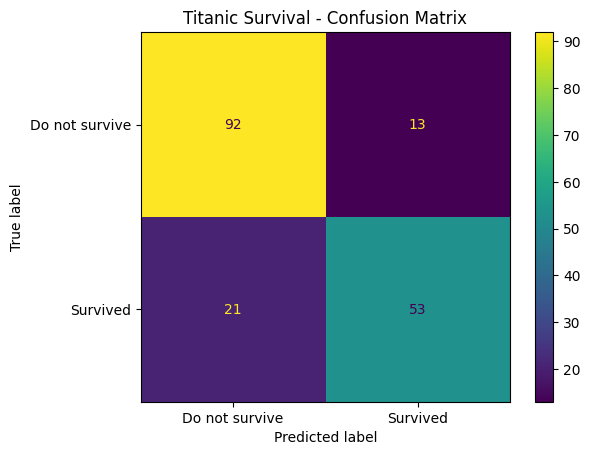

In [27]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Do not survive", "Survived"]
)

disp.plot()
plt.title("Titanic Survival - Confusion Matrix")
plt.show()

## Confusion Matrix Interpretation

The confusion matrix shows that the model correctly predicted 92 passengers who did not survive and 53 passengers who survived. It incorrectly predicted 13 non-survivors as survivors and 21 survivors as non-survivors.

Overall, the model correctly classified 145 out of 179 test passengers, resulting in an accuracy of approximately 81%.

## Conclusion

The Logistic Regression model achieved an accuracy of approximately 81% on the unseen test data. This means the model correctly predicted the survival outcome for about 81% of the test passengers.

The confusion matrix also shows that the model made both correct and incorrect predictions for survivors and non-survivors. Testing on unseen data gives us a more realistic measure of how the model may perform on new passengers.